# Employee Salary Prediction — Final Model & Report
This notebook loads the employee salary dataset, performs robust preprocessing with a scikit-learn `Pipeline` and `ColumnTransformer`, compares several models (LinearRegression, Ridge, Lasso, RandomForest), performs hyperparameter search, evaluates with cross-validation and a held-out test set, and saves the final pipeline to `models/salary_predictor.pkl`.

In [1]:
# Basic imports and reproducibility
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style='whitegrid')

In [2]:
# Locate dataset (tries a few common relative paths)
from pathlib import Path
def locate_csv():
    candidates = [
        Path('data/employee_salary_dataset.csv'),
        Path('../data/employee_salary_dataset.csv'),
        Path('../../data/employee_salary_dataset.csv'),
        Path.cwd() / 'data' / 'employee_salary_dataset.csv',
        Path.cwd().parent / 'data' / 'employee_salary_dataset.csv',
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError('employee_salary_dataset.csv not found; checked: ' + ', '.join(str(p) for p in candidates))

csv_path = locate_csv()
print('Loading data from:', csv_path)
df = pd.read_csv(csv_path)
df.head()

Loading data from: D:\Devprojects\AI\_machine_learning\_deep_learning\employee-salary-prediction\data\employee_salary_dataset.csv


,EmployeeID,Name,Department,Experience_Years,Education_Level,Age,Gender,City,Monthly_Salary
0,1,Employee_1,Marketing,15,Master,53,Female,Delhi,111416
1,2,Employee_2,Operations,7,Bachelor,25,Female,Bangalore,95271
2,3,Employee_3,IT,12,High School,51,Female,Hyderabad,69064
3,4,Employee_4,Operations,8,PhD,44,Male,Delhi,95091
4,5,Employee_5,Operations,15,Master,36,Female,Delhi,132450


In [ ]:
# Quick data audit
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Missing values:' )
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
print('Target (Monthly_Salary) stats:')
print(df['Monthly_Salary'].describe())

Shape: (50, 9)
Dtypes:
EmployeeID          int64
Name                  str
Department            str
Experience_Years    int64
Education_Level       str
Age                 int64
Gender                str
City                  str
Monthly_Salary      int64
dtype: object
Missing values:
EmployeeID          0
Name                0
Department          0
Experience_Years    0
Education_Level     0
Age                 0
Gender              0
City                0
Monthly_Salary      0
dtype: int64
Duplicate rows: 0
Target (Monthly_Salary) stats:
count        50.0000
mean      82288.8000
std       33521.4379
min       28420.0000
25%       59424.0000
50%       73890.5000
75%      107219.0000
max      149123.0000
Name: Monthly_Salary, dtype: float64


## Optional outlier removal (IQR)
Set `REMOVE_OUTLIERS = True` to remove extreme values using the IQR rule. For small datasets this may remove too many rows — you can set it to `False` to keep the original sample.

In [4]:
REMOVE_OUTLIERS = True
outlier_cols = ['Monthly_Salary', 'Experience_Years', 'Age']
n_before = df.shape[0]
if REMOVE_OUTLIERS:
    for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        if n_out > 0:
            print(f'Removing {n_out} outliers from {col} (bounds: {lower:.1f} - {upper:.1f})')
            df = df[~mask]
n_after = df.shape[0]
print(f'Rows: {n_before} -> {n_after}')

Rows: 50 -> 50


In [5]:
# Feature / target selection (drop identifiers)
X = df.drop(columns=['EmployeeID', 'Name', 'Monthly_Salary'])
y = df['Monthly_Salary']
print('Features used:', X.columns.tolist())
print('Sample size:', X.shape[0])

Features used: ['Department', 'Experience_Years', 'Education_Level', 'Age', 'Gender', 'City']
Sample size: 50


In [7]:
# Preprocessing: ColumnTransformer + Pipeline
numeric_features = ['Experience_Years', 'Age']
ordinal_features = ['Education_Level', 'Gender']
categorical_features = ['City', 'Department']

# Define transformers
ordinal_encoder = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD'], ['Male', 'Female']],
                                 handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ordinal_encoder, ordinal_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features),
    ],
    remainder='drop'
)

pipeline_lr = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
pipeline_lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [8]:
# Train/test split and baseline model fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae, rmse, r2 = regression_metrics(y_test, y_pred)
print('Baseline LinearRegression on test set:')
print(f' MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}')

Baseline LinearRegression on test set:
 MAE: 32312.17, RMSE: 41985.13, R2: -0.1819


In [9]:
# Baseline cross-validation (pipeline ensures no leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipeline_lr, X, y, cv=kf, scoring='r2', n_jobs=-1)
print(f'Baseline 5-fold CV R2: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Baseline 5-fold CV R2: -1.1163 ± 1.7019


## Hyperparameter search (Randomized) for Ridge, Lasso, and RandomForest
We use `RandomizedSearchCV` with limited iterations to explore sensible parameter ranges. Results are fit on the training set only.

In [10]:
# Ridge (tuned)
pipeline_ridge = Pipeline([('preprocessor', preprocessor), ('model', Ridge(random_state=RANDOM_STATE))])
param_dist_ridge = {'model__alpha': np.logspace(-6, 6, 200)}
rs_ridge = RandomizedSearchCV(pipeline_ridge, param_distributions=param_dist_ridge, n_iter=30, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
rs_ridge.fit(X_train, y_train)
print('Ridge best params:', rs_ridge.best_params_)
print('Ridge best CV R2:', rs_ridge.best_score_)

Ridge best params: {'model__alpha': np.float64(164467.61779946627)}
Ridge best CV R2: -0.8093877475080179


In [11]:
# Lasso (tuned)
pipeline_lasso = Pipeline([('preprocessor', preprocessor), ('model', Lasso(random_state=RANDOM_STATE, max_iter=20000))])
param_dist_lasso = {'model__alpha': np.logspace(-6, 1, 200)}
rs_lasso = RandomizedSearchCV(pipeline_lasso, param_distributions=param_dist_lasso, n_iter=30, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
rs_lasso.fit(X_train, y_train)
print('Lasso best params:', rs_lasso.best_params_)
print('Lasso best CV R2:', rs_lasso.best_score_)

Lasso best params: {'model__alpha': np.float64(3.489101213406774)}
Lasso best CV R2: -1.3413487676084261


In [12]:
# RandomForest (tuned)
pipeline_rf = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=RANDOM_STATE))])
param_dist_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 3, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt', 'log2']
}
rs_rf = RandomizedSearchCV(pipeline_rf, param_distributions=param_dist_rf, n_iter=40, cv=5, scoring='r2', random_state=RANDOM_STATE, n_jobs=-1)
rs_rf.fit(X_train, y_train)
print('RF best params:', rs_rf.best_params_)
print('RF best CV R2:', rs_rf.best_score_)

RF best params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 20}
RF best CV R2: -0.8125738053947454


In [13]:
# Evaluate all candidates on the held-out test set
models = {
    'LinearRegression': pipeline_lr,
    'Ridge (tuned)': rs_ridge.best_estimator_,
    'Lasso (tuned)': rs_lasso.best_estimator_,
    'RandomForest (tuned)': rs_rf.best_estimator_,
}
results = []
for name, m in models.items():
    y_pred = m.predict(X_test)
    mae, rmse, r2 = regression_metrics(y_test, y_pred)
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}')

import pandas as _pd
results_df = _pd.DataFrame(results).sort_values('RMSE')
results_df

LinearRegression: MAE=32312.17, RMSE=41985.13, R2=-0.1819
Ridge (tuned): MAE=33604.59, RMSE=39057.82, R2=-0.0229
Lasso (tuned): MAE=32294.02, RMSE=41972.20, R2=-0.1812
RandomForest (tuned): MAE=34654.75, RMSE=39984.34, R2=-0.0720


,model,MAE,RMSE,R2
1,Ridge (tuned),33604.586975,39057.819665,-0.022864
3,RandomForest (tuned),34654.745621,39984.343538,-0.071968
2,Lasso (tuned),32294.023132,41972.203571,-0.181205
0,LinearRegression,32312.170089,41985.133143,-0.181933


In [14]:
# Select best model (lowest RMSE) and save it
best_name = results_df.iloc[0]['model']
best_model = models[best_name]
print('Selected best model:', best_name)
os.makedirs('models', exist_ok=True)
model_path = Path('models') / 'salary_predictor.pkl'
joblib.dump(best_model, model_path)
print('Saved pipeline to', model_path)

Selected best model: Ridge (tuned)
Saved pipeline to models\salary_predictor.pkl


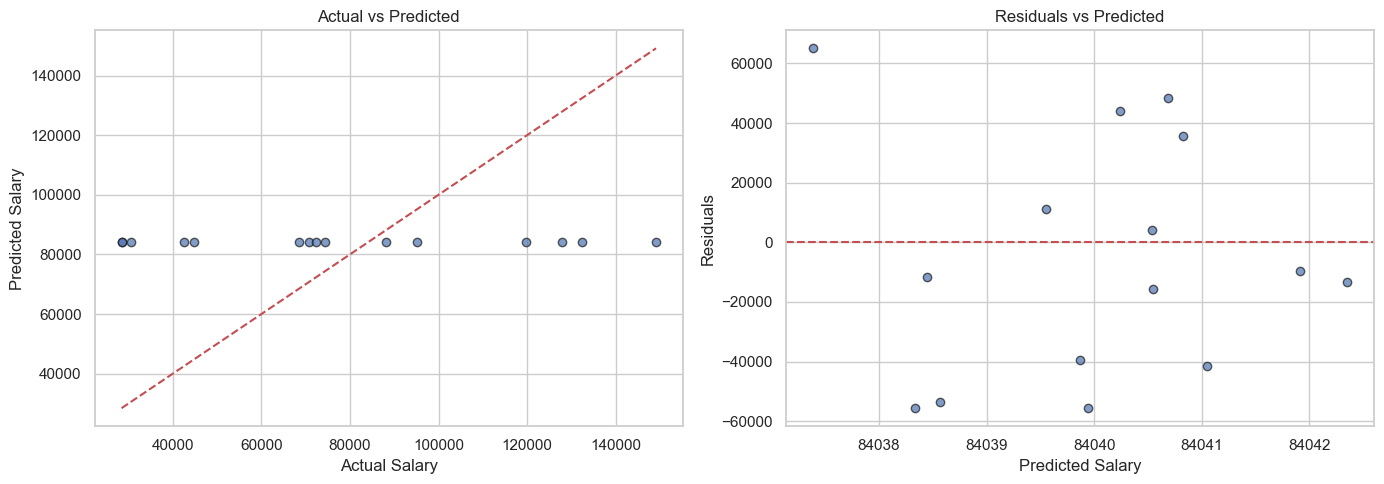

In [15]:
# Diagnostics: Actual vs Predicted and Residuals for best model
y_pred_best = best_model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_best, edgecolors='k', alpha=0.7)
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
axes[0].plot([mn, mx], [mn, mx], 'r--')
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')
axes[0].set_title('Actual vs Predicted')
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, edgecolors='k', alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Salary')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

In [16]:
# Feature importance / coefficients (best model)
pre = best_model.named_steps['preprocessor']
est = best_model.named_steps['model']

def get_feature_names_from_ct(ct, input_features):
    feature_names = []
    for name, trans, cols in ct.transformers_:
        if name == 'remainder':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            try:
                names = list(trans.get_feature_names_out(cols))
            except Exception:
                names = list(cols)
        else:
            names = list(cols)
        feature_names.extend(names)
    return feature_names

feature_names = get_feature_names_from_ct(pre, X.columns)
print('Transformed feature count:', len(feature_names))

import pandas as pd
if hasattr(est, 'coef_'):
    coefs = est.coef_
    feat_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    feat_df = feat_df.reindex(feat_df.coefficient.abs().sort_values(ascending=False).index)
    print('Top coefficients:')
    display(feat_df.head(10))
elif hasattr(est, 'feature_importances_'):
    imps = est.feature_importances_
    feat_df = pd.DataFrame({'feature': feature_names, 'importance': imps})
    feat_df = feat_df.sort_values('importance', ascending=False)
    print('Top feature importances:')
    display(feat_df.head(10))
else:
    print('Model does not expose coefficients or feature_importances_')

Transformed feature count: 12
Top coefficients:


,feature,coefficient
11,Age,0.832507
1,Gender,0.823690
8,Department_Marketing,0.771072
5,City_Mumbai,-0.663253
0,Education_Level,-0.658115
3,City_Delhi,0.607344
2,City_Chennai,-0.571508
9,Department_Operations,-0.434965
10,Experience_Years,0.210908
4,City_Hyderabad,-0.165157


## Summary & Next Steps
- The notebook builds a reproducible `Pipeline` that prevents data leakage during scaling and encoding.
- Models compared: `LinearRegression`, tuned `Ridge`, tuned `Lasso`, tuned `RandomForest`.
- The selected best pipeline is saved to `models/salary_predictor.pkl`.

Next: run the notebook end-to-end (Kernel → Restart & Run All). If you want, I can run the notebook here (if you permit execution), or open a PR with these changes.